In [1]:
import pandas as pd
import numpy as np

# خواندن فایل
try:
    df = pd.read_csv("main_data_filled.csv")

    # 1. ستون response_time_c را با مقادیر میلی‌ثانیه پر می‌کنیم
    # .round() گرد می‌کند
    df['response_time_c'] = (df['response_time'] * 1000).round()

    # 2. محاسبه میانگین و انحراف معیار برای هر caseid
    grouped = df.groupby('caseid')['response_time_c']
    mean_rt = grouped.transform('mean')
    std_rt = grouped.transform('std') # برای گروه‌های با 1 عضو، این مقدار NaN خواهد بود

    # 3. تعریف محدوده‌ها
    lower_bound = 200  # حد پایین (200 میلی‌ثانیه)
    
    # محاسبه حد بالا
    upper_bound = mean_rt + (3 * std_rt)
    
    # رفع مشکل گروه‌های تک‌عضوی:
    # اگر std_rt برابر با NaN باشد، upper_bound هم NaN می‌شود.
    # ما NaNها در upper_bound را با "بی‌نهایت" (np.inf) پر می‌کنیم
    # تا در مقایسه، هیچ مقداری از آن بزرگتر نباشد (و در نتیجه حذف نشود).
    upper_bound = upper_bound.fillna(np.inf)

    # 4. شناسایی داده‌های پرت (خارج از محدوده)
    is_too_low = df['response_time_c'] < lower_bound
    is_too_high = df['response_time_c'] > upper_bound
    
    # ردیفی پرت است که یا خیلی کم باشد یا خیلی زیاد
    is_outlier = is_too_low | is_too_high

    # 5. اعمال درخواست شما: تبدیل ستون به object برای نگهداری مقادیر ترکیبی
    # (اعداد و رشته‌های خالی)
    df['response_time_c'] = df['response_time_c'].astype(object)

    # 6. جایگزینی مقادیر پرت با رشته خالی ''
    df.loc[is_outlier, 'response_time_c'] = ''
    
    # 7. تبدیل مقادیر معتبر (که پرت نبودند) به عدد صحیح (int) برای حذف اعشار .0
    df.loc[~is_outlier, 'response_time_c'] = df.loc[~is_outlier, 'response_time_c'].astype(int)

    # ذخیره نتیجه نهایی در یک فایل جدید
    output_filename = "main_data_filtered_empty.csv"
    df.to_csv(output_filename, index=False)

    print(f"فایل با موفقیت پردازش شد و در '{output_filename}' ذخیره گردید.")

except FileNotFoundError:
    print("خطا: فایل 'main_data_filled.csv' پیدا نشد.")
except Exception as e:
    print(f"یک خطای غیرمنتظره رخ داد: {e}")

فایل با موفقیت پردازش شد و در 'main_data_filtered_empty.csv' ذخیره گردید.


نمودارها با موفقیت در فایل 'rt_analysis_plots_replication.png' ذخیره شدند.


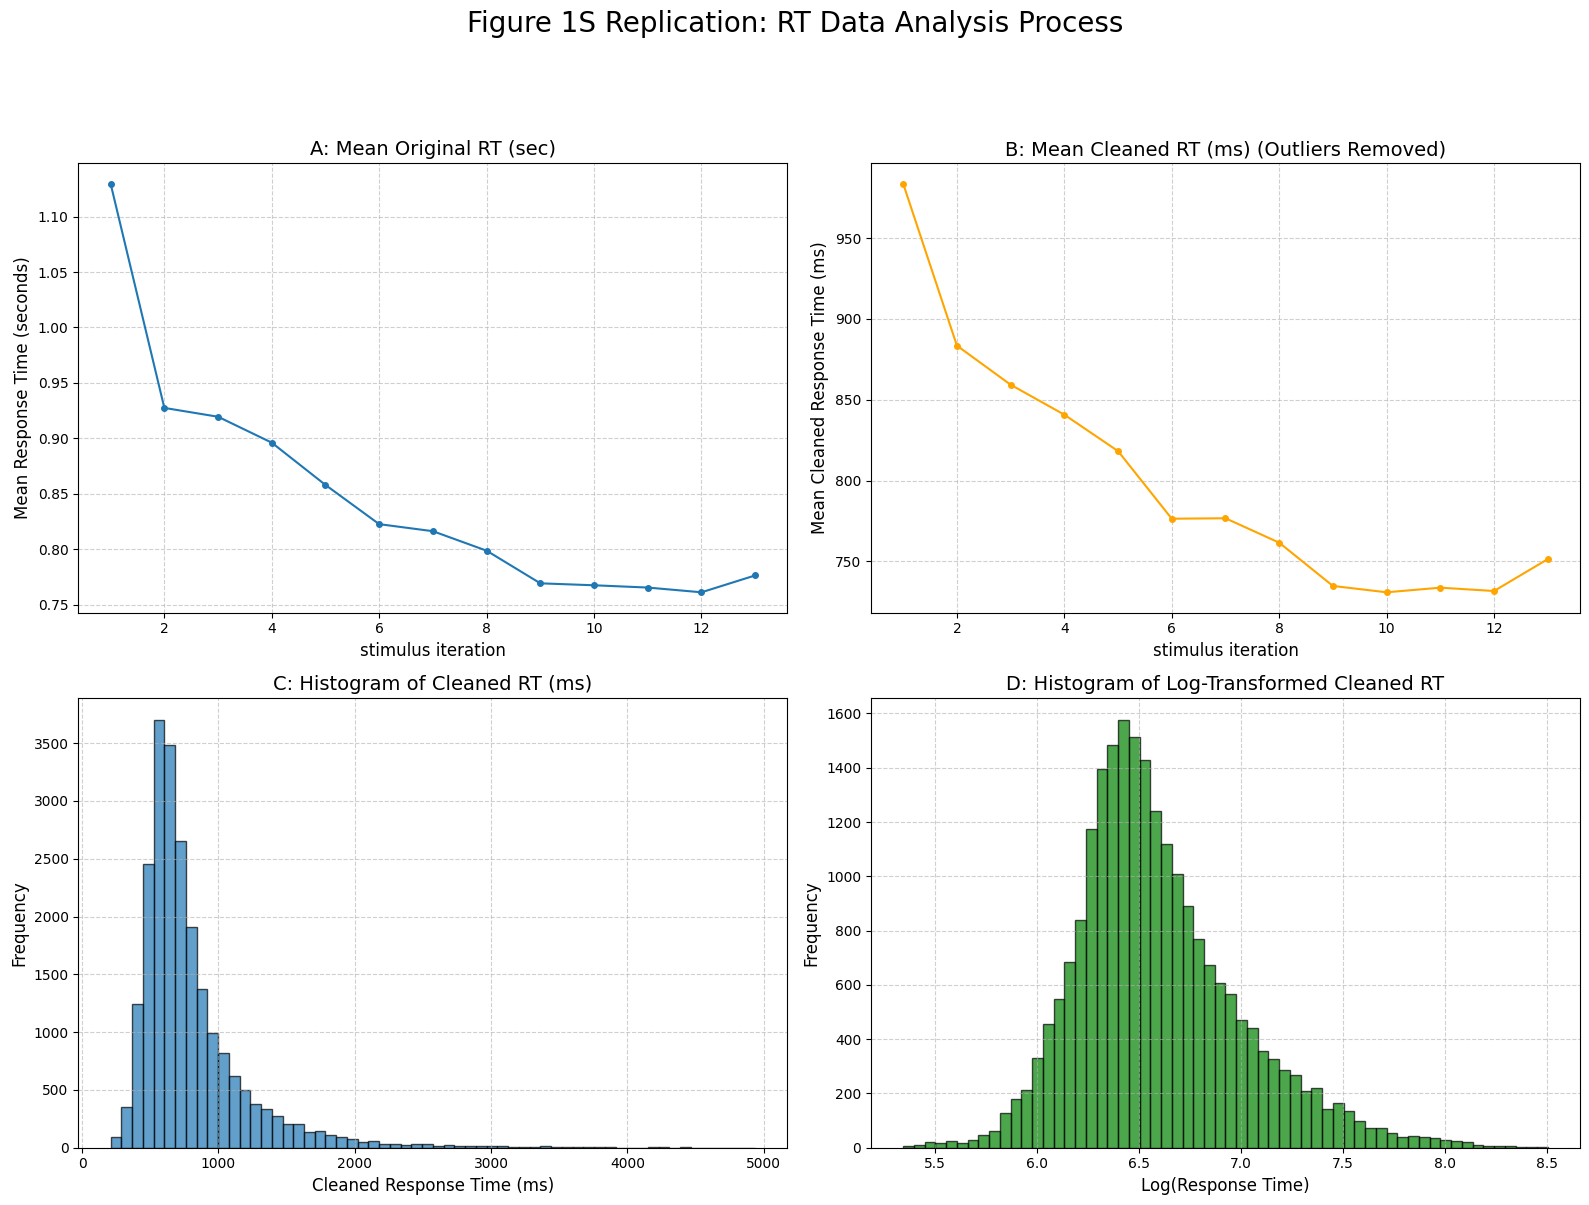

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# خواندن فایل پردازش شده
try:
    df = pd.read_csv("main_data_filtered_empty.csv")

    # آماده‌سازی داده‌ها
    # 1. ستون 'response_time_c' (که حاوی اعداد و رشته‌های خالی است) را به فرمت عددی تبدیل می‌کنیم.
    #    errors='coerce' رشته‌های خالی ('') را به NaN (Not a Number) تبدیل می‌کند.
    rt_ms_cleaned = pd.to_numeric(df['response_time_c'], errors='coerce')
    
    # 2. داده‌های اصلی (به ثانیه) برای نمودار A
    rt_sec_original = df['response_time']
    
    # 3. داده‌های پاک‌شده با تبدیل لگاریتمی (برای نمودار D)
    #    np.log به طور خودکار NaNها را نادیده می‌گیرد
    rt_log_cleaned = np.log(rt_ms_cleaned)

    # ستون trial_iter برای محور X
    trial_iter = df['st_iter']

    # --- ترسیم 4 نمودار در یک تصویر ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Figure 1S Replication: RT Data Analysis Process', fontsize=20, y=1.03)

    # --- نمودار A: میانگین RT اصلی بر اساس شماره آزمون ---
    # ما بر اساس trial_iter گروه بندی می‌کنیم و میانگین response_time اصلی را محاسبه می‌کنیم
    mean_original_rt = rt_sec_original.groupby(trial_iter).mean()
    
    axes[0, 0].plot(mean_original_rt.index, mean_original_rt.values, marker='o', linestyle='-', markersize=4)
    axes[0, 0].set_title('A: Mean Original RT (sec)', fontsize=14)
    axes[0, 0].set_xlabel('stimulus iteration', fontsize=12)
    axes[0, 0].set_ylabel('Mean Response Time (seconds)', fontsize=12)
    axes[0, 0].grid(True, linestyle='--', alpha=0.6)
    # اطمینان از نمایش اعداد صحیح در محور X
    axes[0, 0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))


    # --- نمودار B: میانگین RT پاک‌شده بر اساس شماره آزمون ---
    # ما بر اساس trial_iter گروه بندی می‌کنیم و میانگین response_time_c پاک‌شده را محاسبه می‌کنیم
    mean_cleaned_rt = rt_ms_cleaned.groupby(trial_iter).mean()
    
    axes[0, 1].plot(mean_cleaned_rt.index, mean_cleaned_rt.values, marker='o', linestyle='-', markersize=4, color='orange')
    axes[0, 1].set_title('B: Mean Cleaned RT (ms) (Outliers Removed)', fontsize=14)
    axes[0, 1].set_xlabel('stimulus iteration', fontsize=12)
    axes[0, 1].set_ylabel('Mean Cleaned Response Time (ms)', fontsize=12)
    axes[0, 1].grid(True, linestyle='--', alpha=0.6)
    axes[0, 1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))


    # --- نمودار C: هیستوگرام RT پاک‌شده (ms) ---
    # .dropna() تمام مقادیر NaN (که قبلاً '' بودند) را حذف می‌کند
    axes[1, 0].hist(rt_ms_cleaned.dropna(), bins=60, edgecolor='black', alpha=0.7, color='C0')
    axes[1, 0].set_title('C: Histogram of Cleaned RT (ms)', fontsize=14)
    axes[1, 0].set_xlabel('Cleaned Response Time (ms)', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)


    # --- نمودار D: هیستوگرام RT پاک‌شده (Log-Transformed) ---
    axes[1, 1].hist(rt_log_cleaned.dropna(), bins=60, edgecolor='black', alpha=0.7, color='green')
    axes[1, 1].set_title('D: Histogram of Log-Transformed Cleaned RT', fontsize=14)
    axes[1, 1].set_xlabel('Log(Response Time)', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)


    # --- ذخیره فایل ---
    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # تنظیم فاصله برای عنوان اصلی
    output_image_filename = 'rt_analysis_plots_replication.png'
    plt.savefig(output_image_filename)

    print(f"نمودارها با موفقیت در فایل '{output_image_filename}' ذخیره شدند.")

except FileNotFoundError:
    print(f"خطا: فایل 'main_data_filtered_empty.csv' پیدا نشد.")
except Exception as e:
    print(f"یک خطای غیرمنتظره رخ داد: {e}")

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# --- 1. Load Data ---
try:
    df = pd.read_csv("main_data_filtered_empty.csv")
    print(f"Successfully loaded 'main_data_filtered_empty.csv'. Total rows: {len(df)}")
except FileNotFoundError:
    print("Error: 'main_data_filtered_empty.csv' not found.")
    df = None 
except Exception as e:
    print(f"An error occurred loading the file: {e}")
    df = None

if df is not None:
    
    # --- 2. Define Variables ---
    
    # Predictors (Independent Variables)
    predictor_cols = ['rpred', 'delay', 'Block', 'block', 'conflict']
    
    # Dependent Variable (Outcome)
    dv_col = 'response_time_c'
    
    # Columns needed for analysis
    all_cols = predictor_cols + [dv_col]
    
    # Create a copy for analysis
    df_analysis = df[all_cols].copy()
    
    # --- 3. Data Preprocessing ---
    
    # A. Convert 'response_time_c' to numeric. 
    # Empty strings ('') will become NaN
    df_analysis[dv_col] = pd.to_numeric(df_analysis[dv_col], errors='coerce')
    
    # B. **NEW: Apply Log-Transformation to the Dependent Variable**
    # We create a new column 'rt_log'. 
    # np.log() will naturally handle NaNs.
    # It will also produce -inf for 0 or NaN for negative numbers (if any).
    df_analysis['rt_log'] = np.log(df_analysis[dv_col])
    
    # C. Prepare data for Linear Regression
    # We must drop rows where 'rt_log' is NaN or infinite (e.g., from log(0))
    # or where any predictor is NaN.
    
    # Replace infinities with NaN so .dropna() catches them
    df_analysis.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Drop rows with NaN in the *log-transformed* DV or any predictor
    df_linear = df_analysis.dropna(subset=['rt_log'] + predictor_cols)
    print(f"Rows for Linear Regression (predicting 'rt_log'): {len(df_linear)}")
    
    X_linear = df_linear[predictor_cols]
    y_linear = df_linear['rt_log'] # Use the log-transformed DV

    # --- 4. Z-score Predictors ---
    # "All regressors were z scored before entering into the regression model."
    
    scaler_linear = StandardScaler()
    
    # Z-score for Linear model data
    X_linear_z = scaler_linear.fit_transform(X_linear)
    X_linear_z = pd.DataFrame(X_linear_z, columns=predictor_cols, index=X_linear.index)
    X_linear_z = sm.add_constant(X_linear_z, prepend=False) # Add intercept term 'const'

    print("-" * 40)
    
    # --- 5. Model: Linear Regression (Predicting 'Log(RT)') ---
    print(f"\n--- Model: Linear Regression (Predicting 'rt_log') ---")
    try:
        linear_model = sm.OLS(y_linear, X_linear_z)
        linear_result = linear_model.fit()
        print(linear_result.summary())
        
        linear_params = linear_result.params

    except Exception as e:
        print(f"Error running Linear Regression: {e}")
        linear_params = None

    print("=" * 40)

Successfully loaded 'main_data_filtered_empty.csv'. Total rows: 23112
Rows for Linear Regression (predicting 'rt_log'): 22649
----------------------------------------

--- Model: Linear Regression (Predicting 'rt_log') ---
                            OLS Regression Results                            
Dep. Variable:                 rt_log   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     714.3
Date:                Thu, 30 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:26:33   Log-Likelihood:                -10078.
No. Observations:               22649   AIC:                         2.017e+04
Df Residuals:                   22643   BIC:                         2.022e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                             